In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as sm

from pygments.styles.dracula import background
from sklearn.linear_model import LinearRegression
from IPython.display import display_html
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

path = "CSV/Balaji Fast Food Sales.csv"
df = pd.read_csv(path)
df

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
0,1,2022-07-03,Aalopuri,Fastfood,20,13,260,NaN,Mr.,Night
1,2,2022-08-23,Vadapav,Fastfood,20,15,300,Cash,Mr.,Afternoon
2,3,2022-11-20,Vadapav,Fastfood,20,1,20,Cash,Mr.,Afternoon
3,4,2023-02-03,Sugarcane juice,Beverages,25,6,150,Online,Mr.,Night
4,5,2022-10-02,Sugarcane juice,Beverages,25,8,200,Online,Mr.,Evening
...,...,...,...,...,...,...,...,...,...,...
995,996,2023-03-19,Frankie,Fastfood,50,10,500,NaN,Mrs.,Evening
996,997,2022-09-20,Sandwich,Fastfood,60,7,420,NaN,Mr.,Evening
997,998,2023-01-26,Sandwich,Fastfood,60,13,780,NaN,Mr.,Evening
998,999,2022-08-27,Panipuri,Fastfood,20,5,100,NaN,Mrs.,Afternoon


In [32]:
num_types = df.groupby(by='item_name').size()
display(num_types);

item_name
Aalopuri           134
Cold coffee        161
Frankie            139
Panipuri           150
Sandwich           129
Sugarcane juice    153
Vadapav            134
dtype: int64

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            1000 non-null   int64 
 1   date                1000 non-null   object
 2   item_name           1000 non-null   object
 3   item_type           1000 non-null   object
 4   item_price          1000 non-null   int64 
 5   quantity            1000 non-null   int64 
 6   transaction_amount  1000 non-null   int64 
 7   transaction_type    893 non-null    object
 8   received_by         1000 non-null   object
 9   time_of_sale        1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [34]:
df.describe(include='all')

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
count,1000.000000,1000,1000,1000,1000.000000,1000.000000,1000.000000,893,1000,1000
unique,NaN,348,7,2,NaN,NaN,NaN,2,2,5
top,NaN,2022-08-31,Cold coffee,Fastfood,NaN,NaN,NaN,Cash,Mr.,Night
freq,NaN,8,161,686,NaN,NaN,NaN,476,512,205
mean,500.500000,NaN,NaN,NaN,33.315000,8.162000,275.230000,NaN,NaN,NaN
std,288.819436,NaN,NaN,NaN,14.921744,4.413075,204.402979,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,20.000000,1.000000,20.000000,NaN,NaN,NaN
25%,250.750000,NaN,NaN,NaN,20.000000,4.000000,120.000000,NaN,NaN,NaN
50%,500.500000,NaN,NaN,NaN,25.000000,8.000000,240.000000,NaN,NaN,NaN
75%,750.250000,NaN,NaN,NaN,50.000000,12.000000,360.000000,NaN,NaN,NaN


array([[<Axes: title={'center': 'order_id'}>,
        <Axes: title={'center': 'item_price'}>],
       [<Axes: title={'center': 'quantity'}>,
        <Axes: title={'center': 'transaction_amount'}>]], dtype=object)

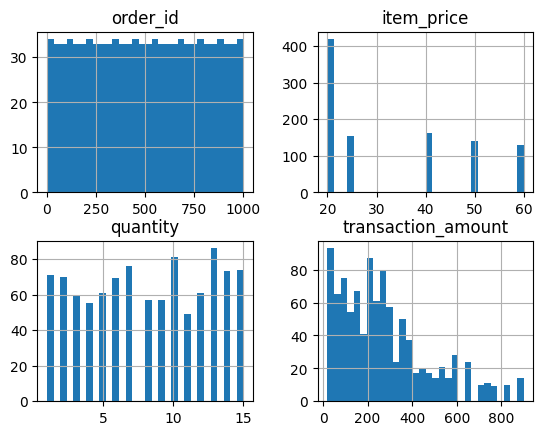

In [35]:
df.hist(bins=30)

In [36]:
y = df[['transaction_amount']]
X = df[['quantity', 'item_price']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
lin_model = sm.ols(formula='transaction_amount ~ quantity + item_price', data=df).fit()
print(lin_model.params, "\n")
print(lin_model.summary())

Intercept    -264.653249
quantity       32.491503
item_price      8.245163
dtype: float64 

                            OLS Regression Results                            
Dep. Variable:     transaction_amount   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.897
Method:                 Least Squares   F-statistic:                     4337.
Date:                Mon, 08 Dec 2025   Prob (F-statistic):               0.00
Time:                        16:46:38   Log-Likelihood:                -5602.4
No. Observations:                1000   AIC:                         1.121e+04
Df Residuals:                     997   BIC:                         1.123e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

In [38]:
results = []
names = []
models = [('LinearRegression', LinearRegression())]
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    result = np.sqrt(mean_squared_error(y_test, y_pred))
    results.append(result)
    names.append(name)
    msg = "%s: %f" % (name, result)
    print(msg)


LinearRegression: 64.387998


In [39]:
y_pred = lin_model.predict(X_test)
y_pred

521    322.639551
737    360.022532
740     62.707524
660    375.045414
411    396.356869
          ...    
408    192.673537
332    298.882358
208    -34.766987
613    -34.766987
78      95.199027
Length: 200, dtype: float64

In [40]:
mean_squared_error(y_test, y_pred)

4129.452586394769

In [41]:
lin_model2 = LinearRegression(positive = True)
lin_model2.fit(X_train, y_train)
y_pred = lin_model2.predict(X_test)

mean_squared_error(y_test, y_pred)

4145.814322092227

In [42]:
df_sample = df.sample(n=10, random_state = 152)

def highlight_cols(s):
    color = 'null'
    if s == 'Morning': color = 'green'
    elif s == 'Evening': color = 'blue'
    elif s == 'Night': color = 'orange'
    elif s == 'Afternoon': color = 'pink'
    elif s == 'Midnight': color = 'purple'
    return 'background-color: % s' % color

df_sample.style.map(highlight_cols)

,order_id,date,item_name,item_type,item_price,quantity,transaction_amount,transaction_type,received_by,time_of_sale
235,236,2022-06-26,Vadapav,Fastfood,20,12,240,nan,Mrs.,Evening
473,474,2022-08-28,Sugarcane juice,Beverages,25,15,375,Cash,Mrs.,Night
563,564,2022-09-27,Cold coffee,Beverages,40,2,80,nan,Mr.,Morning
320,321,2023-02-08,Frankie,Fastfood,50,12,600,Cash,Mrs.,Evening
977,978,2022-10-08,Frankie,Fastfood,50,2,100,Online,Mr.,Night
302,303,2022-07-02,Sugarcane juice,Beverages,25,1,25,Cash,Mrs.,Midnight
698,699,2022-09-09,Cold coffee,Beverages,40,1,40,Online,Mr.,Evening
707,708,2023-03-15,Sandwich,Fastfood,60,5,300,Cash,Mrs.,Midnight
206,207,2023-02-20,Cold coffee,Beverages,40,8,320,Online,Mrs.,Evening
105,106,2023-02-25,Frankie,Fastfood,50,9,450,Cash,Mrs.,Evening


<Axes: >

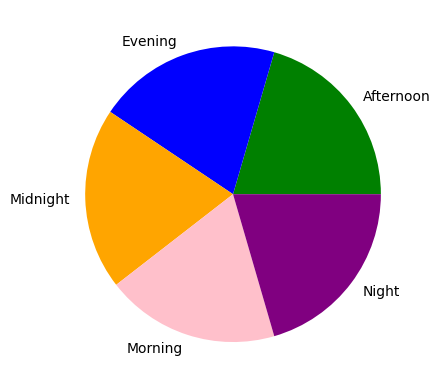

In [43]:
df.groupby('time_of_sale').size().plot(kind='pie',colors = ['green','blue','orange','pink','purple'])

In [44]:
after_pd_dummy = pd.get_dummies(df_sample)
print(after_pd_dummy)

     order_id  item_price  quantity  transaction_amount  date_2022-06-26  \
235       236          20        12                 240             True   
473       474          25        15                 375            False   
563       564          40         2                  80            False   
320       321          50        12                 600            False   
977       978          50         2                 100            False   
302       303          25         1                  25            False   
698       699          40         1                  40            False   
707       708          60         5                 300            False   
206       207          40         8                 320            False   
105       106          50         9                 450            False   

     date_2022-07-02  date_2022-08-28  date_2022-09-09  date_2022-09-27  \
235            False            False            False            False   
473          

In [45]:
def highlight_dummy_cols(cols):
    if cols.name == 'time_of_sale_Morning':
        return ['background-color: green' if c == 1 else '' for c in cols.values]
    elif cols.name == 'Afternoon':
        return ['background-color: pink' if c == 1 else '' for c in cols.values]
    elif cols.name == 'time_of_sale_Evening':
        return ['background-color: blue' if c == 1 else '' for c in cols.values]
    elif cols.name == 'time_of_sale_Night':
        return ['background-color: orange' if c == 1 else '' for c in cols.values]
    elif cols.name == 'time_of_sale_Midnight':
        return ['background-color: purple' if c == 1 else '' for c in cols.values]
    else:
        return ['background-color: null' for c in cols.values]

In [46]:
before_styler = df_sample[['time_of_sale']].style.set_table_attributes("style='display:inline'").set_caption('Before').map(highlight_cols).format(precision = 1)

after_styler = after_pd_dummy[['time_of_sale_Morning', 'time_of_sale_Evening', 'time_of_sale_Night', 'time_of_sale_Midnight']].style.set_table_attributes("style='display:inline'").set_caption('After <em>get_dummy</em>').apply(highlight_dummy_cols).format(precision = 1)

space = "\xa0" * 10

arrow = '<table style="width:5%"> \
    <tr> \
        <th> <br> <br> <big><big><big><big><big>&#8680;</big></big></big></big></big> <br> <br> </th> \
    </tr>'

display_html(before_styler._repr_html_() + space + after_styler._repr_html_(), raw=True)


,time_of_sale
235,Evening
473,Night
563,Morning
320,Evening
977,Night
302,Midnight
698,Evening
707,Midnight
206,Evening
105,Evening


In [47]:
keep_cats = df[['quantity', 'item_price']]
X = pd.get_dummies(keep_cats)
y = df[['transaction_amount']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.333, random_state=41)
lin_model_times = LinearRegression()
lin_model_times.fit(X_train, y_train)
y_pred = lin_model_times.predict(X_test)

sme = mean_squared_error(y_test, y_pred)
print('MSE using times is : ' + str(sme))

MSE using times is : 4703.279631049637


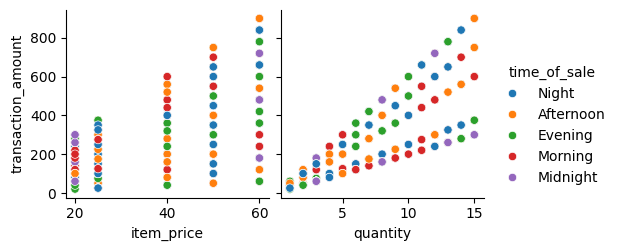

In [48]:
sns.pairplot(df, x_vars= ['item_price', 'quantity'], y_vars= ['transaction_amount'], hue= 'time_of_sale')

In [49]:
df_dummy = pd.get_dummies(df)

df_Mo = df_dummy.loc[df_dummy['time_of_sale_Morning'] == 1].drop(columns=['time_of_sale_Evening', 'time_of_sale_Night', 'time_of_sale_Midnight'])

df_E = df_dummy.loc[df_dummy['time_of_sale_Evening'] == 1].drop(columns=['time_of_sale_Morning', 'time_of_sale_Night', 'time_of_sale_Midnight'])

df_N = df_dummy.loc[df_dummy['time_of_sale_Night'] == 1].drop(columns=['time_of_sale_Morning', 'time_of_sale_Evening', 'time_of_sale_Midnight'])

df_Mi = df_dummy.loc[df_dummy['time_of_sale_Midnight'] == 1].drop(columns=['time_of_sale_Morning', 'time_of_sale_Evening', 'time_of_sale_Night'])

def line_reg_pipe(df_list):
    for df in df_list:
        X = df[['item_price', 'quantity']]
        y = df[['transaction_amount']]

        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.333, random_state=41)

        line_reg_model_a = LinearRegression()
        line_reg_model_a.fit(X_train,y_train)

        y_pred = line_reg_model_a.predict(X_test)
        sme = mean_squared_error(y_test, y_pred)

        print('MSE of ' + df.columns[4] + ' is : ' + str(sme))
df_list = [df_Mo, df_E, df_N, df_Mi]
line_reg_pipe(df_list)

MSE of date_2022-04-01 is : 4952.006836638524
MSE of date_2022-04-01 is : 3845.433533520756
MSE of date_2022-04-01 is : 3769.1816212810054
MSE of date_2022-04-01 is : 4109.492186405539


In [50]:
mean_squared_error(y_test, y_pred)

4703.279631049637

In [51]:
r2_score(y_test, y_pred)

0.8929067939641699

In [52]:
def prompt_interactive_menu(df_list):

    # Display menu options
    print("Please type an option listed below to the prompt box (1, 2, 3, 4) and then click the OK button in the prompt box:\n")
    print("\t 1. Overall mean")
    print("\t 2. Mean for times of sale")
    print("\t 3. R2 accuracy score")
    print("\t 4. R2 exit")
    valid_options = [1, 2, 3, 4]

    # Prompt the user for option selection:
    option = None

    while option is None:
        user_input = input("\nEnter your option selection here: ")

        if user_input.isdigit() and int(user_input) in valid_options:
            option = int(user_input)
        else:
            print("Error: Invalid option provided.")

    # Process the option selected by the end-user:
    if option == 1: print("Overall mean: ", mean_squared_error(y_test, y_pred))
    if option == 2: print("Mean for times of sales (listed in order of Morning, Evening, Night, and Midnight): ", line_reg_pipe(df_list))
    if option == 3: print("R2 accuracy score: ", r2_score(y_test, y_pred))
    if option == 4:
        print("The program will now close.")
        quit()


In [54]:
prompt_interactive_menu(df_list)


Please type an option listed below to the prompt box (1, 2, 3, 4) and then click the OK button in the prompt box:

	 1. Overall mean
	 2. Mean for times of sale
	 3. R2 accuracy score
	 4. R2 exit



Enter your option selection here:  3


R2 accuracy score:  0.8929067939641699
